In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/Superstore.csv"

# Try with latin1 encoding
df = pd.read_csv(file_path, encoding='latin1')

# Preview the data
print("Dataset loaded with latin1 encoding:")

Dataset loaded with latin1 encoding:


In [ ]:
-#What are the 25th, 50th, and 75th percentiles of Sales and profit

sales_percentiles = df['Sales'].quantile([0.25, 0.5, 0.75, 0.9])
profit_percentiles = df['Profit'].quantile([0.25, 0.5, 0.75, 0.9])
print(sales_percentiles)
print(profit_percentiles)


0.25     17.280
0.50     54.490
0.75    209.940
0.90    572.706
Name: Sales, dtype: float64
0.25     1.72875
0.50     8.66650
0.75    29.36400
0.90    89.28162
Name: Profit, dtype: float64


In [ ]:
#Divide sales into quartiles. Which quartile has the highest share of Technology orders?

df['Sales_Quartile'] = pd.qcut(df['Sales'], 4, labels=["Q1", "Q2", "Q3", "Q4"])
tech_counts = df[df['Category'] == 'Technology']['Sales_Quartile'].value_counts()
print(tech_counts)



Sales_Quartile
Q4    825
Q3    645
Q2    297
Q1     80
Name: count, dtype: int64


In [ ]:
a=df['Profit'].quantile(.9)
b=df['Profit'].quantile(1)
c=df[(a<=df['Profit'])& (df['Profit']>=b)]
print(df.groupby('Segment')['Quantity'].sum())

Segment
Consumer       19521
Corporate      11608
Home Office     6744
Name: Quantity, dtype: int64


In [ ]:
counts2=df[df['Category']=='Technology'].groupby("Sales_Quartile").size()
print(counts2)

Sales_Quartile
Q1     80
Q2    297
Q3    645
Q4    825
dtype: int64


/tmp/ipython-input-3530390451.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts2=df[df['Category']=='Technology'].groupby("Sales_Quartile").size()


In [ ]:
#What is the spread between Q1 and Q3 of Profit?

Q1_profit = df['Profit'].quantile(0.25)
Q3_profit = df['Profit'].quantile(0.75)
print("Profit Spread (Q3 - Q1):", Q3_profit - Q1_profit)


Profit Spread (Q3 - Q1): 27.63525


In [ ]:
#What are the 3rd and 7th deciles of Sales?

deciles = df['Sales'].quantile([i/10 for i in range(1,10)])
print(deciles)


0.1      7.8972
0.2     13.7760
0.3     21.4544
0.4     34.2480
0.5     54.4900
0.6     89.8096
0.7    158.3760
0.8    281.3720
0.9    572.7060
Name: Sales, dtype: float64


In [ ]:
#Which customer segment dominates the top decile (D9) of Profit?

top_decile_threshold = df['Profit'].quantile(0.9)
top_decile_segment = df[df['Profit'] >= top_decile_threshold]['Segment'].value_counts()
print(top_decile_segment)


Segment
Consumer       483
Corporate      322
Home Office    195
Name: count, dtype: int64


In [ ]:
a=df['Profit'].quantile(.9)
#b=df['Profit'].quantile(1)
c=df[(a<=df['Profit'])]
print(c.groupby("Segment").size())

Segment
Consumer       483
Corporate      322
Home Office    195
dtype: int64


In [ ]:
#What is the IQR of Profit?

Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
print("IQR:", IQR)



IQR: 27.63525


In [ ]:
#Which categories show outlier profits?

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]

print("Outliers by Category:\n", outliers['Category'].value_counts())


Outliers by Category:
 Category
Office Supplies    685
Furniture          627
Technology         569
Name: count, dtype: int64


In [ ]:
#Which region has the most volatile sales (highest variance)?

variance_by_region = df.groupby('Region')['Sales'].var()
print(variance_by_region)


Region
Central    400409.275802
East       385284.196615
South      600309.263888
West       275495.736259
Name: Sales, dtype: float64


In [ ]:
#Which has higher standard deviation: Profit or Discount?

print("Profit SD:", df['Profit'].std())
print("Discount SD:", df['Discount'].std())


Profit SD: 234.26010769095757
Discount SD: 0.2064519678256984


In [ ]:
#Is the Sales distribution skewed left or right?

print("Sales Skewness:", df['Sales'].skew())
print("Profit Skewness:", df['Profit'].skew())



Sales Skewness: 12.97275234181623
Profit Skewness: 7.561431562468343


In [ ]:
#Does Profit show high kurtosis (fat tails)?

print("Sales Kurtosis:", df['Sales'].kurt())
print("Profit Kurtosis:", df['Profit'].kurt())


Sales Kurtosis: 305.311753246823
Profit Kurtosis: 397.1885145524141


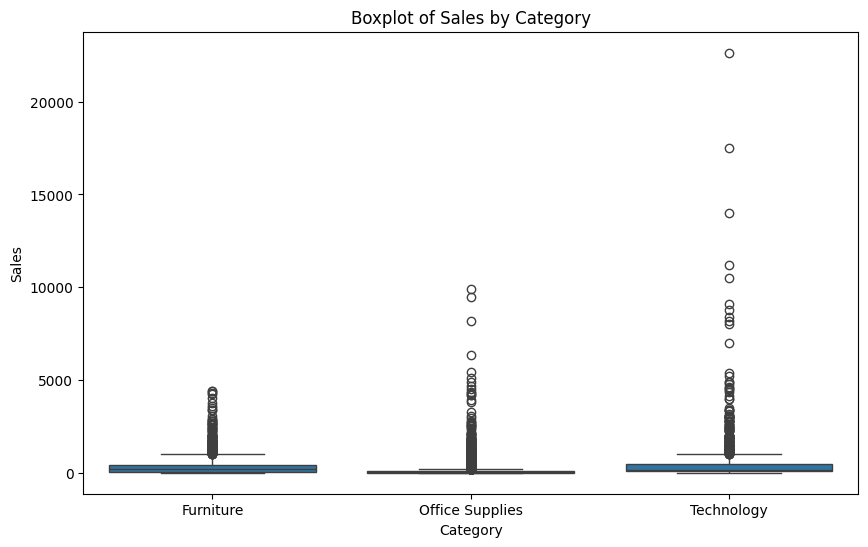

In [ ]:
#Draw a boxplot of Sales by Category. Which category shows the widest spread?

plt.figure(figsize=(10,6))
sns.boxplot(x='Category', y='Sales', data=df)
plt.title("Boxplot of Sales by Category")
plt.show()



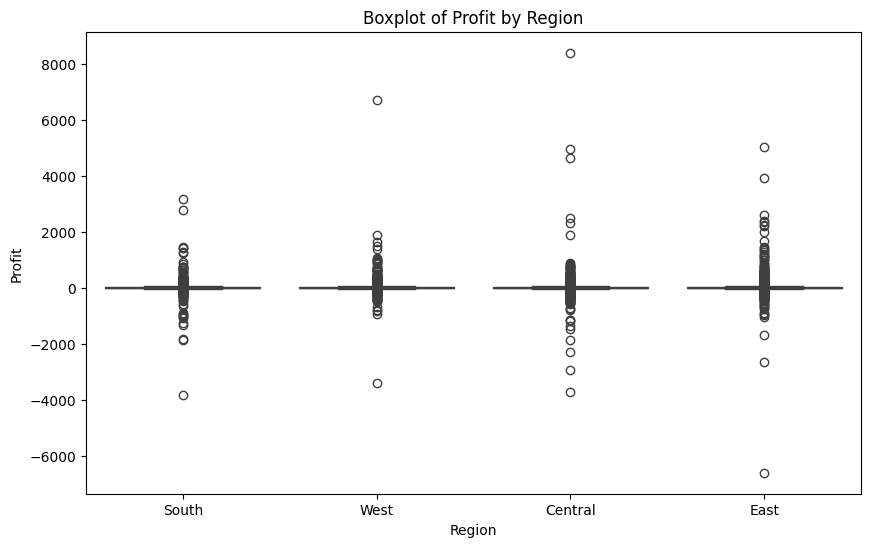

In [ ]:
#Which region has the most profit outliers?

plt.figure(figsize=(10,6))
sns.boxplot(x='Region', y='Profit', data=df)
plt.title("Boxplot of Profit by Region")
plt.show()


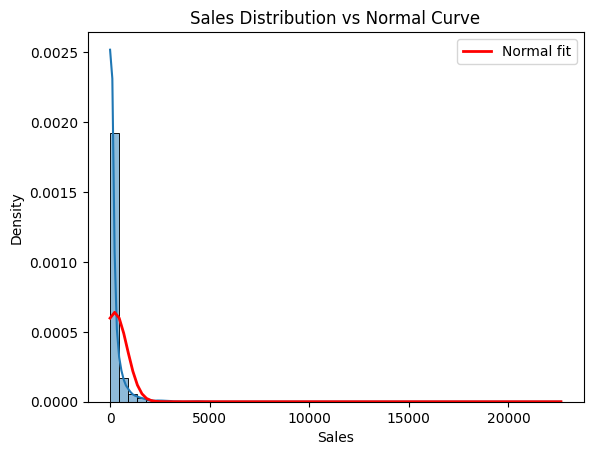

In [ ]:
#Plot a histogram of Sales and check if it looks Normal.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Histogram of Sales with normal fit
mu_sales, sigma_sales = df['Sales'].mean(), df['Sales'].std()
sns.histplot(df['Sales'], kde=True, stat="density", bins=50)
x = np.linspace(df['Sales'].min(), df['Sales'].max(), 100)
plt.plot(x, norm.pdf(x, mu_sales, sigma_sales), 'r-', lw=2, label="Normal fit")
plt.legend()
plt.title("Sales Distribution vs Normal Curve")
plt.show()


In [ ]:
# Assuming Normality of Profit, what is the probability that profit lies between ₹0 and ₹100?

# Probability Profit between 0 and 100
mu_profit, sigma_profit = df['Profit'].mean(), df['Profit'].std()
p_0_100 = norm.cdf(100, mu_profit, sigma_profit) - norm.cdf(0, mu_profit, sigma_profit)
print("P(0 <= Profit <= 100):", p_0_100)

P(0 <= Profit <= 100): 0.1683251485478673


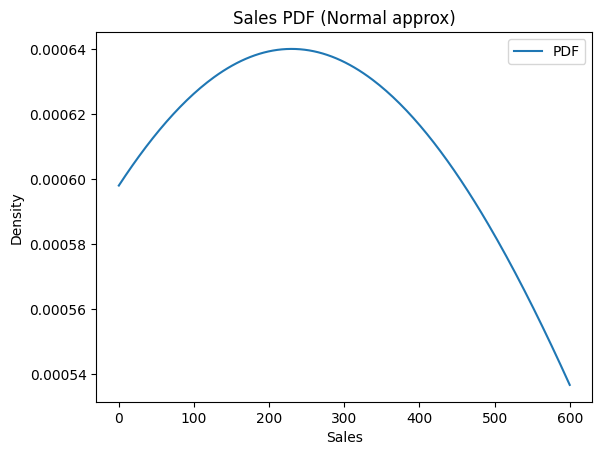

In [ ]:
# Plot PDF of Sales. What does its value at x=200 mean?
mu, sigma = df['Sales'].mean(), df['Sales'].std()
x = np.linspace(0, 600, 200)

pdf_vals = norm.pdf(x, mu, sigma)
plt.plot(x, pdf_vals, label="PDF")
plt.title("Sales PDF (Normal approx)")
plt.xlabel("Sales"); plt.ylabel("Density"); plt.legend(); plt.show()


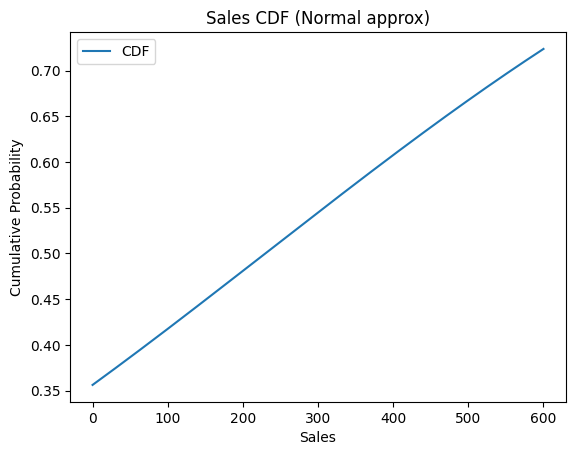

In [ ]:
# Plot CDF of sales
cdf_vals = norm.cdf(x, mu, sigma)
plt.plot(x, cdf_vals, label="CDF")
plt.title("Sales CDF (Normal approx)")
plt.xlabel("Sales"); plt.ylabel("Cumulative Probability"); plt.legend(); plt.show()